# Análise estatística do dataset do EscutIA

Este notebook mostra, com tabelas e gráficos, o que aconteceu com os dados depois da preparação. A análise ajuda a responder perguntas importantes antes do treinamento: as classes estão equilibradas? Os conjuntos têm tamanhos adequados? Existem textos muito curtos, muito longos, repetidos ou rejeitados?

O notebook não altera o dataset. Ele apenas lê os arquivos produzidos pelo Dataset_EscutIA.ipynb e registra um resumo estatístico em dados/relatorios/12_analise_estatistica.json.

## Antes de começar

Execute primeiro o notebook Dataset_EscutIA.ipynb até o resultado DATA_READY_FOR_SFT. Depois, execute as células deste notebook na ordem.

A análise usa a fonte unificada, os arquivos preparados de treino, validação e avaliação, os registros rejeitados e o relatório da validação final. A avaliação congelada será observada, mas não será usada para alterar os dados.

In [1]:
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'dados').exists() and (BASE_DIR / 'EscutIA' / 'dataset' / 'dados').exists():
    BASE_DIR = BASE_DIR / 'EscutIA' / 'dataset'

DATA_DIR = BASE_DIR / 'dados'
PREPARED_DIR = DATA_DIR / 'preparados'
REPORTS_DIR = DATA_DIR / 'relatorios'
SOURCE_FILE = DATA_DIR / 'dataset.csv'

if not SOURCE_FILE.exists():
    raise FileNotFoundError('Execute primeiro o Dataset_EscutIA.ipynb até a etapa de validação final.')
if not PREPARED_DIR.exists():
    raise FileNotFoundError(f'Pasta de preparados não encontrada: {PREPARED_DIR}')

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Pasta analisada: {BASE_DIR}')


Pasta analisada: c:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\dataset


## 1. Visão geral da fonte e dos arquivos preparados

Primeiro comparamos a fonte unificada com os três conjuntos que serão usados no SFT. Essa comparação mostra quanto foi preservado e como os dados foram distribuídos.

In [2]:
def ler_json(caminho):
    return json.loads(caminho.read_text(encoding='utf-8'))

def ler_jsonl(caminho):
    return [json.loads(linha) for linha in caminho.read_text(encoding='utf-8').splitlines() if linha.strip()]

df_origem = pd.read_csv(SOURCE_FILE, encoding='utf-8-sig')
arquivos_splits = {
    'treino': PREPARED_DIR / 'escutia_train.json',
    'validacao': PREPARED_DIR / 'escutia_validation.json',
    'avaliacao': PREPARED_DIR / 'escutia_evaluation.json',
}
splits = {nome: pd.DataFrame(ler_json(caminho)) for nome, caminho in arquivos_splits.items()}

resumo_arquivos = pd.DataFrame({
    'arquivo': ['dataset.csv'] + [caminho.name for caminho in arquivos_splits.values()],
    'conjunto': ['origem_unificada'] + list(arquivos_splits.keys()),
    'registros': [len(df_origem)] + [len(df) for df in splits.values()],
})
display(resumo_arquivos)
display(df_origem.head())


,arquivo,conjunto,registros
0,dataset.csv,origem_unificada,3063
1,escutia_train.json,treino,1833
2,escutia_validation.json,validacao,612
3,escutia_evaluation.json,avaliacao,612


,id,texto,rotulo
0,1,Acordei animado e com vontade de começar o dia.,positivo
1,2,Foi muito bom conversar com meus amigos ontem.,positivo
2,3,Estou orgulhoso do resultado que consegui no t...,positivo
3,4,Hoje encontrei uma solução para um problema di...,positivo
4,5,Sinto esperança de que as coisas vão melhorar.,positivo


## 2. Distribuição dos sentimentos

A distribuição dos rótulos é uma das primeiras verificações de qualidade. Se uma classe aparecer muito mais do que as outras, o modelo poderá aprender a preferir essa classe, mesmo quando a resposta correta for diferente.

output,negativo,neutro,positivo,total
treino,612,610,611,1833
validacao,204,204,204,612
avaliacao,204,204,204,612


output,negativo,neutro,positivo
treino,33.39%,33.28%,33.33%
validacao,33.33%,33.33%,33.33%
avaliacao,33.33%,33.33%,33.33%


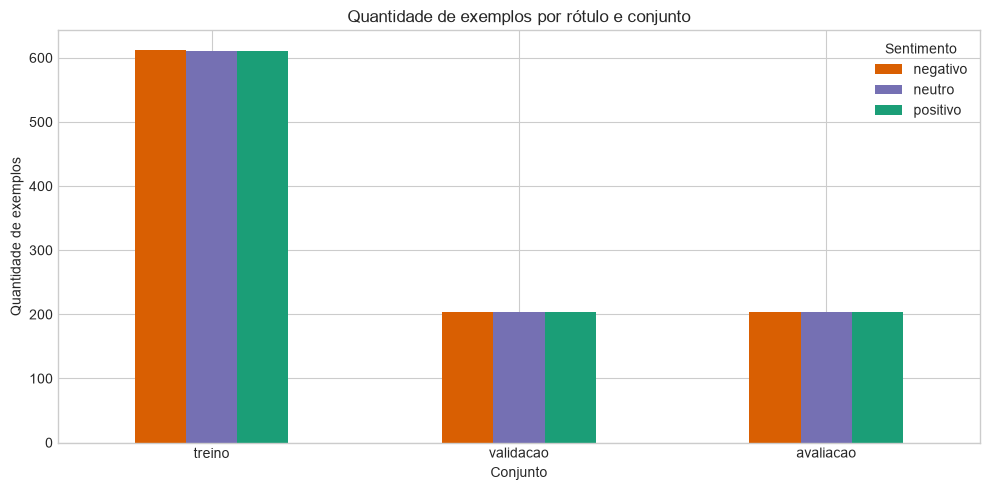

In [3]:
rotulos = ['negativo', 'neutro', 'positivo']
distribuicao = pd.DataFrame({
    nome: df['output'].value_counts().reindex(rotulos, fill_value=0)
    for nome, df in splits.items()
}).T
distribuicao['total'] = distribuicao.sum(axis=1)
percentuais = distribuicao[rotulos].div(distribuicao['total'], axis=0).mul(100).round(2)

display(distribuicao)
display(percentuais.style.format('{:.2f}%'))

ax = distribuicao[rotulos].plot(kind='bar', figsize=(10, 5), color=['#d95f02', '#7570b3', '#1b9e77'])
ax.set_title('Quantidade de exemplos por rótulo e conjunto')
ax.set_xlabel('Conjunto')
ax.set_ylabel('Quantidade de exemplos')
ax.legend(title='Sentimento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Tamanho dos textos e identificação de outliers

Textos muito curtos podem ter pouco contexto. Textos muito longos podem consumir mais tokens e aumentar o custo do treinamento. Por isso, observamos a quantidade de caracteres e palavras sem remover registros automaticamente.

caracteres                        palavras                      
               count   mean median min  max    count   mean median min max
conjunto                                                                  
avaliacao        612  72.90   67.0  21  140      612  11.97   11.0   2  30
treino          1833  72.74   67.0  19  145     1833  11.87   11.0   2  29
validacao        612  72.13   67.0  18  140      612  11.74   11.0   2  28

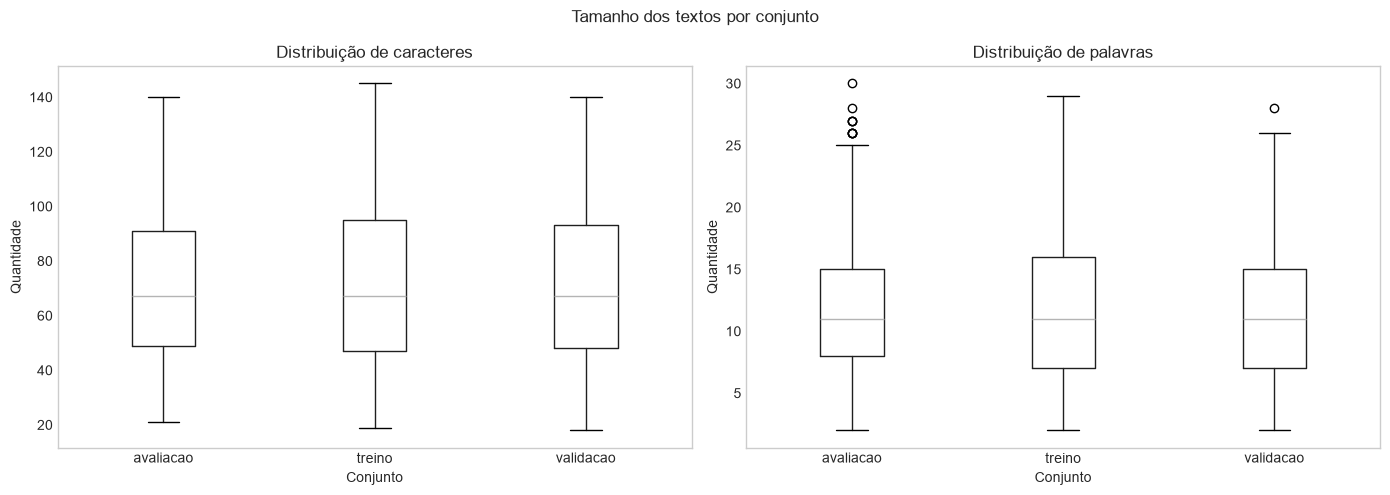

In [4]:
tamanhos = []
for nome, df in splits.items():
    copia = df.copy()
    copia['caracteres'] = copia['input'].astype(str).str.len()
    copia['palavras'] = copia['input'].astype(str).str.split().str.len()
    copia['conjunto'] = nome
    tamanhos.append(copia[['conjunto', 'caracteres', 'palavras']])
df_tamanhos = pd.concat(tamanhos, ignore_index=True)

resumo_tamanho = df_tamanhos.groupby('conjunto')[['caracteres', 'palavras']].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
display(resumo_tamanho)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
df_tamanhos.boxplot(column='caracteres', by='conjunto', ax=eixos[0], grid=False)
df_tamanhos.boxplot(column='palavras', by='conjunto', ax=eixos[1], grid=False)
eixos[0].set_title('Distribuição de caracteres')
eixos[1].set_title('Distribuição de palavras')
for eixo in eixos:
    eixo.set_xlabel('Conjunto')
    eixo.set_ylabel('Quantidade')
fig.suptitle('Tamanho dos textos por conjunto')
plt.tight_layout()
plt.show()


## 4. Registros rejeitados e problemas encontrados

A quantidade de rejeitados deve ser explicada. Um registro não desaparece sem justificativa: ele é preservado nos arquivos de trabalho com o motivo da separação.

,arquivo,registros
0,04_rejeitados.jsonl,0
1,05_rejeitados.jsonl,6


,motivo,quantidade
1,CONFLITO_DE_ROTULO,4
0,DUPLICATA_DE_TEXTO,2


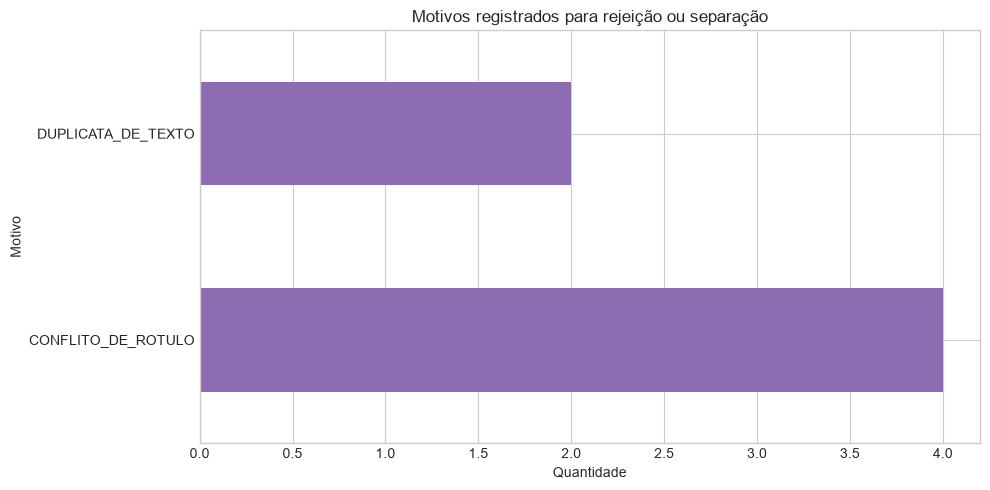

In [5]:
arquivos_rejeitados = [
    DATA_DIR / 'trabalho' / '04_rejeitados.jsonl',
    DATA_DIR / 'trabalho' / '05_rejeitados.jsonl',
]
contagem_motivos = Counter()
resumo_rejeitados = []

for caminho in arquivos_rejeitados:
    if not caminho.exists():
        continue
    registros = ler_jsonl(caminho)
    for registro in registros:
        motivos = registro.get('motivos') or [registro.get('motivo', 'motivo não informado')]
        contagem_motivos.update(motivos)
    resumo_rejeitados.append({'arquivo': caminho.name, 'registros': len(registros)})

display(pd.DataFrame(resumo_rejeitados))
df_motivos = pd.DataFrame(contagem_motivos.items(), columns=['motivo', 'quantidade']).sort_values('quantidade', ascending=False)
display(df_motivos)

if not df_motivos.empty:
    ax = df_motivos.plot.barh(x='motivo', y='quantidade', figsize=(10, 5), legend=False, color='#8c6bb1')
    ax.set_title('Motivos registrados para rejeição ou separação')
    ax.set_xlabel('Quantidade')
    ax.set_ylabel('Motivo')
    plt.tight_layout()
    plt.show()


## 5. Duplicidades e isolamento dos conjuntos

A mesma entrada não deve aparecer em mais de um conjunto. Também verificamos duplicidades dentro de cada conjunto usando uma chave normalizada para a comparação.

In [6]:
def chave_comparacao(texto):
    return ' '.join(str(texto).casefold().split())

chaves_por_conjunto = {
    nome: {chave_comparacao(texto) for texto in df['input']}
    for nome, df in splits.items()
}
duplicidades_internas = {
    nome: int(df['input'].map(chave_comparacao).duplicated().sum())
    for nome, df in splits.items()
}
sobreposicoes = []
for esquerda, direita in [('treino', 'validacao'), ('treino', 'avaliacao'), ('validacao', 'avaliacao')]:
    comuns = chaves_por_conjunto[esquerda] & chaves_por_conjunto[direita]
    sobreposicoes.append({'conjunto_a': esquerda, 'conjunto_b': direita, 'textos_em_comum': len(comuns)})

display(pd.DataFrame([{'conjunto': nome, 'duplicidades_internas': quantidade} for nome, quantidade in duplicidades_internas.items()]))
display(pd.DataFrame(sobreposicoes))


,conjunto,duplicidades_internas
0,treino,0
1,validacao,0
2,avaliacao,0


,conjunto_a,conjunto_b,textos_em_comum
0,treino,validacao,0
1,treino,avaliacao,0
2,validacao,avaliacao,0


## 6. Comparação entre Alpaca e conversacional

Os dois formatos representam a mesma tarefa. A diferença está na forma como a instrução e a resposta são organizadas para o LLaMA-Factory.

In [7]:
arquivos_conversacionais = {
    nome: PREPARED_DIR / f'escutia_{"train" if nome == "treino" else "validation" if nome == "validacao" else "evaluation"}_conversacional.json'
    for nome in splits
}
resumo_formatos = []
for nome, caminho in arquivos_conversacionais.items():
    registros = ler_json(caminho)
    mensagens_validas = sum(
        len(registro.get('messages', [])) == 3
        and [mensagem.get('role') for mensagem in registro.get('messages', [])] == ['system', 'user', 'assistant']
        for registro in registros
    )
    resumo_formatos.append({'conjunto': nome, 'alpaca': len(splits[nome]), 'conversacional': len(registros), 'conversas_validas': mensagens_validas})

display(pd.DataFrame(resumo_formatos))


,conjunto,alpaca,conversacional,conversas_validas
0,treino,1833,1833,1833
1,validacao,612,612,612
2,avaliacao,612,612,612


## 7. Gate e resumo da análise

A análise estatística não substitui a validação final. Ela ajuda a interpretar os dados e a identificar sinais que merecem investigação. O treinamento só deve avançar quando o gate da preparação estiver aprovado.

In [8]:
gate_path = REPORTS_DIR / '11_validacao_final.json'
gate = ler_json(gate_path) if gate_path.exists() else {'decisao': 'RELATORIO_NAO_ENCONTRADO'}
display(pd.DataFrame([{'gate': gate.get('decisao', 'não informado')}]))

if gate.get('decisao') == 'DATA_READY_FOR_SFT':
    display(Markdown('**Resultado:** os dados foram preparados e o gate DATA_READY_FOR_SFT está aprovado.'))
else:
    display(Markdown('**Resultado:** o gate ainda não está aprovado. Revise o notebook de preparação antes de treinar.'))

relatorio_analise = {
    'fonte_unificada': len(df_origem),
    'conjuntos': {nome: len(df) for nome, df in splits.items()},
    'distribuicao_rotulos': distribuicao[rotulos].to_dict(),
    'duplicidades_internas': duplicidades_internas,
    'sobreposicoes_entre_conjuntos': sobreposicoes,
    'motivos_rejeicao': dict(contagem_motivos),
    'gate_preparacao': gate.get('decisao'),
}
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
(REPORTS_DIR / '12_analise_estatistica.json').write_text(json.dumps(relatorio_analise, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(f'Relatório salvo em: {REPORTS_DIR / "12_analise_estatistica.json"}')


,gate
0,DATA_READY_FOR_SFT


**Resultado:** os dados foram preparados e o gate DATA_READY_FOR_SFT está aprovado.

Relatório salvo em: c:\Users\mdbaa\development\alura\alura-llama-factory\EscutIA\dataset\dados\relatorios\12_analise_estatistica.json


## Conclusão

Nesta análise observamos a composição, a distribuição, o tamanho e a qualidade dos dados preparados. Os gráficos não provam sozinhos que o modelo terá bom desempenho, mas fornecem evidências para entender o dataset antes do treinamento.

O próximo passo pode usar o dataset preparado no módulo de treinamento com LoRA ou QLoRA. A avaliação congelada deve continuar reservada para comparar o modelo base com o modelo especializado.